In [1]:
import numpy as np
import nengo
import sys

import logging
# logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, format="[%(name)s/%(levelname)s]: %(message)s")
logging.basicConfig(stream=sys.stdout, level=logging.INFO, format="[%(name)s/%(levelname)s]: %(message)s")

import nengo_aie

model = nengo.Network()

dt = 1e-3

with model:
    A = nengo.Ensemble(100, dimensions=1, neuron_type=nengo_aie.AIELif(100, dt))
    A_squared = nengo.Ensemble(100, dimensions=1)
    error = nengo.Ensemble(100, dimensions=1)

    conn = nengo.Connection(A, A_squared)

    conn.learning_rule_type = nengo.PES(learning_rate=3e-4)

    nengo.Connection(error, conn.learning_rule)

    nengo.Connection(A_squared, error)

    nengo.Connection(A, error, function=lambda x: x**2, transform=-1)

with model:
    input_node = nengo.Node(output=lambda t: int(6 * t / 5) / 3.0 % 2 - 1)

    # nengo_aie.AIEConnection(input_node, A)
    nengo.Connection(input_node, A)

    stop_learning = nengo.Node(output=lambda t: t >= 15)

    nengo.Connection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1))) # This one is the one that calls elementwise inc
    # nengo_aie.AIEConnection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1)))

with model:
    input_node_probe = nengo.Probe(input_node)
    A_probe = nengo.Probe(A, synapse=0.01)
    A_squared_probe = nengo.Probe(A_squared, synapse=0.01)
    error_probe = nengo.Probe(error, synapse=0.01)
    learn_probe = nengo.Probe(stop_learning, synapse=None)

with nengo_aie.AIESimulator(model, dt=dt) as sim:
    sim.run(20)

[nengo_aie.aie_kernels.KernelManager/INFO]: Compiling kernels
[nengo_aie.simulator/INFO]: Initializing simulator
[nengo_aie.builder/INFO]: Initialied builder


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[nengo.simulator/INFO]: Running <Network (unlabeled) at 0x782f1c39e8a0>, dt=0.001000 for 20.000000 seconds, or 20000 steps


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[matplotlib.font_manager/INFO]: generated new fontManager


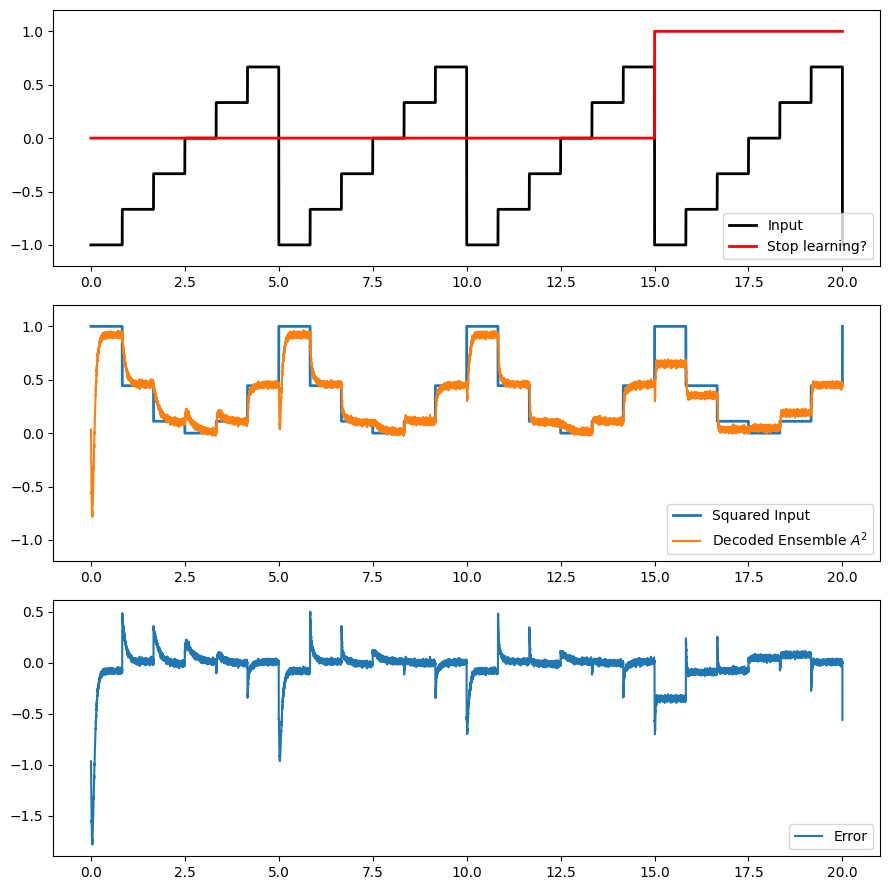

In [3]:
import matplotlib
# matplotlib.pyplot.set_loglevel (level = 'warning')

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))
plt.subplot(3, 1, 1)
plt.plot(
    sim.trange(), sim.data[input_node_probe], label="Input", color="k", linewidth=2.0
)
plt.plot(
    sim.trange(),
    sim.data[learn_probe],
    label="Stop learning?",
    color="r",
    linewidth=2.0,
)
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 2)
plt.plot(
    sim.trange(), sim.data[input_node_probe] ** 2, label="Squared Input", linewidth=2.0
)
plt.plot(sim.trange(), sim.data[A_squared_probe], label="Decoded Ensemble $A^2$")
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 3)
plt.plot(
    sim.trange(),
    sim.data[A_squared_probe] - sim.data[input_node_probe] ** 2,
    label="Error",
)
plt.legend(loc="lower right")
plt.tight_layout()

In [ ]:
import ml_dtypes
np.asarray([2.4065964e-38], dtype=np.float32).view(np.uint8)

In [ ]:
a = np.asarray([1, 2])
np.concatenate([a, a])